# ST-GNN 예측 시각화
**최고 성능 모델**: window=12 / S3_transport_pm10_pollutants / static  
**Test MAE: 2.61 µg/m³ | RMSE: 3.73 µg/m³**

In [1]:
import sys
sys.path.insert(0, '/workspace/ST-GNN Modeling')

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import pandas as pd
from torch.utils.data import DataLoader

from dataset import load_scenario_split, STGNNScenarioDataset
from graph_builder import (
    compute_all_dynamic_edge_features,
    get_full_edge_features,
)
from model import STGNNModel

# ── 한글 폰트 설정 (기본 스타일 유지, Korean 지원만 추가) ──
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.sans-serif'] = ['NanumGothic'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 설정 ──
SCENARIO    = 'S3_transport_pm10_pollutants'
GRAPH_MODE  = 'static'
WINDOW      = 12
CHECKPOINT  = f'/workspace/ST-GNN Modeling/checkpoints/window_{WINDOW}/{SCENARIO}/{GRAPH_MODE}/best_model.pt'
GRAPH_DIR   = '/workspace/ST-GNN Modeling/graphs'
GAT_HIDDEN  = 64
GRU_HIDDEN  = 64
NUM_HEADS   = 4
BATCH_SIZE  = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
import os, pickle

# ── 데이터 로드 ──
(train_nodes, val_nodes, test_nodes,
 train_mask,  val_mask,  test_mask,
 coords, feature_cols) = load_scenario_split(SCENARIO)

stations = sorted(
    pd.read_csv(
        f'/home/data/youngwoong/ST-GNN_Dataset/Data_Preprocessed/ST-GNN/feature_scenarios/{SCENARIO}.csv'
    )['측정소명'].unique()
)

# test timestamps (window 이후부터 예측 대상)
with open('/workspace/ST-GNN Modeling/split_info.pkl', 'rb') as f:
    split_info = pickle.load(f)
test_times = sorted(split_info['test_times'])
pred_times = pd.to_datetime(test_times[WINDOW:])

pm10_idx = feature_cols.index('PM10')

# ── 정규화 ──
feat_min = train_nodes.min(axis=(0, 1), keepdims=True)
feat_max = train_nodes.max(axis=(0, 1), keepdims=True)

def minmax(arr):
    return (arr - feat_min) / (feat_max - feat_min + 1e-8)

test_norm = minmax(test_nodes)
pm10_min  = float(feat_min[0, 0, pm10_idx])
pm10_max  = float(feat_max[0, 0, pm10_idx])

N = test_nodes.shape[1]
F = test_nodes.shape[2]
print(f'Stations: {N} | Features: {F} | Test timesteps: {len(test_times)}')
print(f'PM10 range (train): {pm10_min:.1f} ~ {pm10_max:.1f} µg/m³')

Stations: 40 | Features: 9 | Test timesteps: 2744
PM10 range (train): 1.0 ~ 536.0 µg/m³


In [3]:
# ── 그래프 로드 ──
graph_path = os.path.join(GRAPH_DIR, GRAPH_MODE)
edge_index_np  = np.load(os.path.join(graph_path, 'edge_index.npy'))
static_attr_np = np.load(os.path.join(graph_path, 'static_attr.npy'))
edge_bearings  = np.load(os.path.join(graph_path, 'edge_bearings.npy'))
E = edge_index_np.shape[1]

T = test_nodes.shape[0]
dyn = compute_all_dynamic_edge_features(edge_index_np, test_nodes, edge_bearings)
static_rep = np.broadcast_to(static_attr_np[None], (T, E, 3)).copy()
test_edges = get_full_edge_features(static_rep, dyn)

edge_index_t = torch.from_numpy(edge_index_np).long().to(device)

test_ds = STGNNScenarioDataset(
    node_features=torch.from_numpy(test_norm),
    edge_index=edge_index_t.cpu(),
    edge_features_all=torch.from_numpy(test_edges),
    window=WINDOW,
    mask=torch.from_numpy(test_mask) if test_mask is not None else None,
    pm10_idx=pm10_idx,
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Test samples: {len(test_ds)}')

Test samples: 2732


In [4]:
# ── 모델 로드 & 추론 ──
model = STGNNModel(
    node_dim=F, edge_dim=5,
    gat_hidden=GAT_HIDDEN, gru_hidden=GRU_HIDDEN,
    num_heads=NUM_HEADS, num_nodes=N,
).to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()

all_pred, all_true, all_attn = [], [], []
with torch.no_grad():
    for node_w, edge_w, target, _ in test_loader:
        pred, _, attn = model(node_w.to(device), edge_index_t, edge_w.to(device))
        all_pred.append(pred.cpu().numpy())
        all_true.append(target.cpu().numpy())
        all_attn.append(attn.cpu().numpy())   # [T, E, H]

# 역정규화 → μg/m³
pred_arr = np.concatenate(all_pred, axis=0)[:, :, 0] * (pm10_max - pm10_min) + pm10_min  # [T, N]
true_arr = np.concatenate(all_true, axis=0)[:, :, 0] * (pm10_max - pm10_min) + pm10_min  # [T, N]

# attention: list of [T=12, E, H=4] per batch → mean over batches & window → [E, H]
attn_per_batch = np.stack(all_attn, axis=0)          # [n_batches, T, E, H]
attn_mean      = attn_per_batch.mean(axis=(0, 1))    # [E, H]  — 전체 평균

flat_pred = pred_arr.ravel()
flat_true = true_arr.ravel()

n = len(flat_true)
k = F

mae_total  = np.mean(np.abs(flat_pred - flat_true))
rmse_total = np.sqrt(np.mean((flat_pred - flat_true) ** 2))
ss_res = np.sum((flat_true - flat_pred) ** 2)
ss_tot = np.sum((flat_true - flat_true.mean()) ** 2)
r2     = 1 - ss_res / ss_tot
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f'Test MAE:       {mae_total:.2f} μg/m³')
print(f'Test RMSE:      {rmse_total:.2f} μg/m³')
print(f'Test R²:        {r2:.4f}')
print(f'Test Adj. R²:   {adj_r2:.4f}  (n={n}, k={k})')
print(f'Attention shape: {attn_per_batch.shape}  →  mean: {attn_mean.shape}')

Test MAE:       2.61 μg/m³
Test RMSE:      3.73 μg/m³
Test R²:        0.8800
Test Adj. R²:   0.8799  (n=109280, k=9)
Attention shape: (43, 12, 706, 4)  →  mean: (706, 4)


## 1. 예측 vs 실제: 산점도

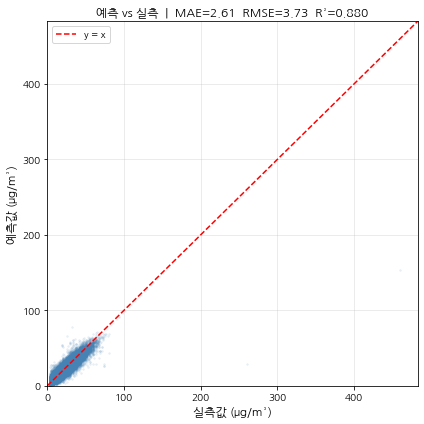

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(flat_true, flat_pred, alpha=0.08, s=3, color='steelblue', rasterized=True)

lim = max(flat_true.max(), flat_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='y = x')

ax.set_xlabel('실측값 (μg/m³)', fontsize=12)
ax.set_ylabel('예측값 (μg/m³)', fontsize=12)
ax.set_title(f'예측 vs 실측  |  MAE={mae_total:.2f}  RMSE={rmse_total:.2f}  R²={r2:.3f}', fontsize=12)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/scatter_pred_vs_true.png', dpi=180, bbox_inches='tight')
plt.show()

## 2. 오차 분포 히스토그램

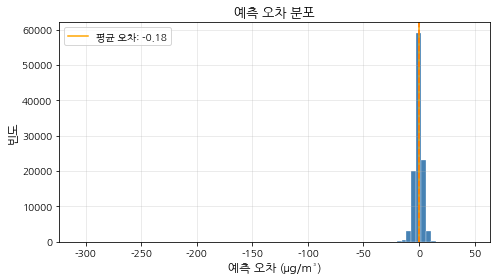

In [6]:
errors = (pred_arr - true_arr).ravel()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(errors, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', lw=1.5, linestyle='--')
ax.axvline(errors.mean(), color='orange', lw=1.5, linestyle='-', label=f'평균 오차: {errors.mean():.2f}')
ax.set_xlabel('예측 오차 (μg/m³)', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title('예측 오차 분포', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/error_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. 시계열: 예측 vs 실측 (전체 평균)

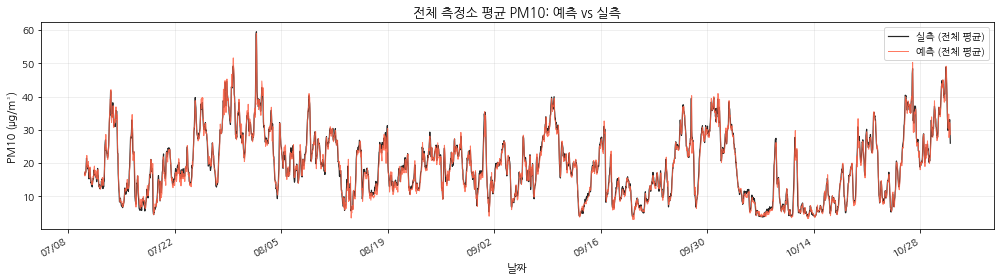

In [7]:
mean_pred = pred_arr.mean(axis=1)  # [T]
mean_true = true_arr.mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pred_times, mean_true, label='실측 (전체 평균)', color='black', lw=1.2, alpha=0.85)
ax.plot(pred_times, mean_pred, label='예측 (전체 평균)', color='tomato',  lw=1.0, alpha=0.85)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.set_xlabel('날짜', fontsize=11)
ax.set_ylabel('PM10 (μg/m³)', fontsize=11)
ax.set_title('전체 측정소 평균 PM10: 예측 vs 실측', fontsize=13)
ax.legend()
ax.grid(alpha=0.25)
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('plots/timeseries_mean.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. 시계열: 개별 측정소 (상위 4개 + 하위 4개, MAE 기준)

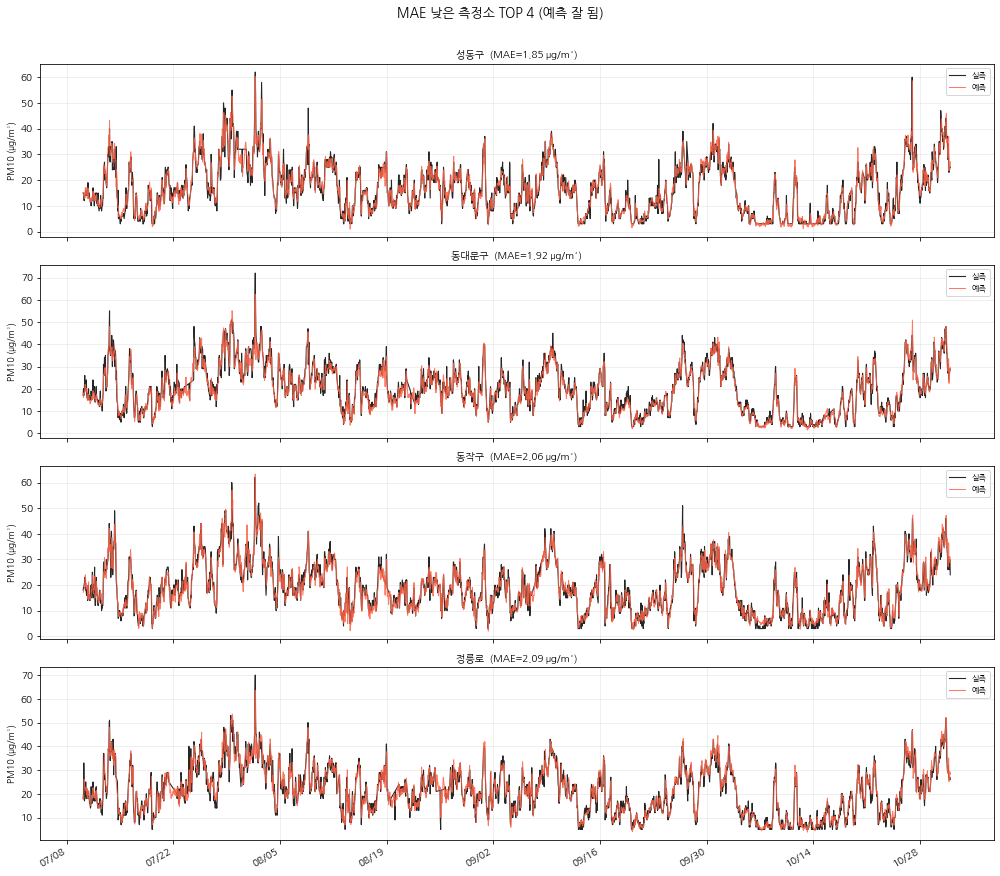

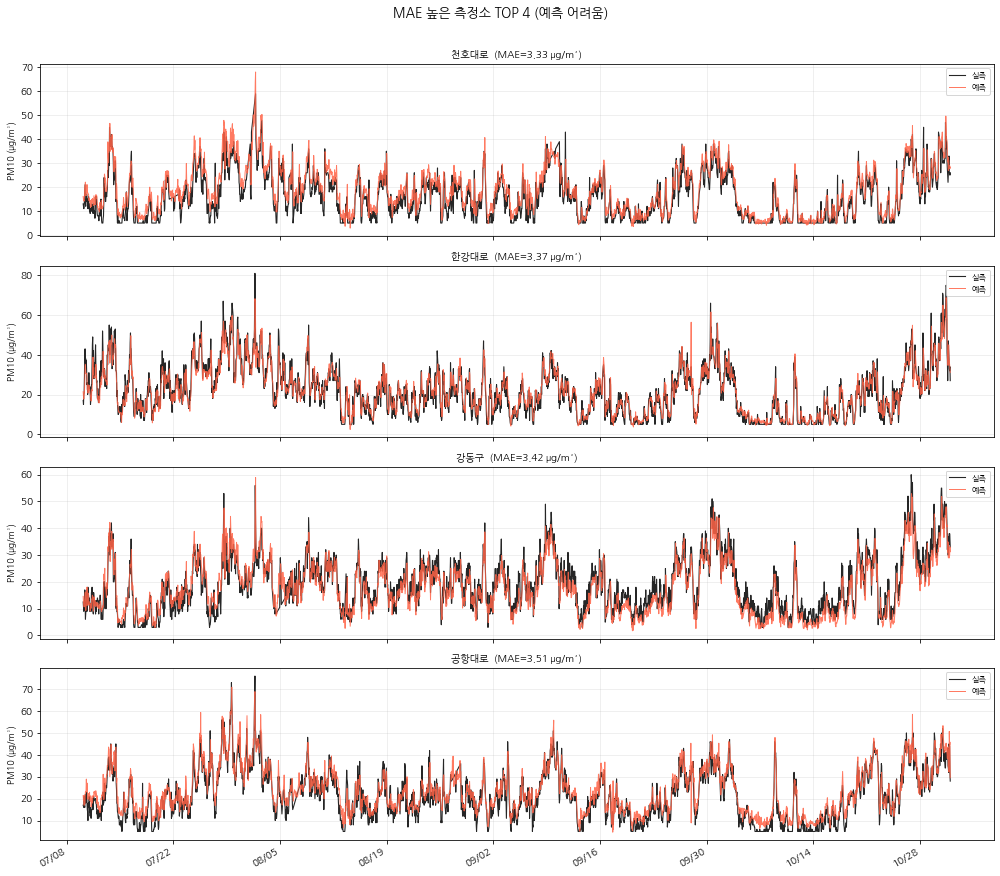

In [8]:
station_mae = np.mean(np.abs(pred_arr - true_arr), axis=0)  # [N]
sorted_idx  = np.argsort(station_mae)
best4  = sorted_idx[:4]
worst4 = sorted_idx[-4:]

def plot_station_ts(idxs, title, fname):
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    for ax, si in zip(axes, idxs):
        ax.plot(pred_times, true_arr[:, si], label='실측', color='black', lw=1.1, alpha=0.85)
        ax.plot(pred_times, pred_arr[:, si], label='예측', color='tomato',  lw=1.0, alpha=0.85)
        ax.set_ylabel('PM10 (μg/m³)', fontsize=9)
        ax.set_title(f'{stations[si]}  (MAE={station_mae[si]:.2f} μg/m³)', fontsize=10)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, loc='upper right')
    axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    fig.autofmt_xdate()
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'plots/{fname}', dpi=180, bbox_inches='tight')
    plt.show()

plot_station_ts(best4,  'MAE 낮은 측정소 TOP 4 (예측 잘 됨)', 'timeseries_best4.png')
plot_station_ts(worst4, 'MAE 높은 측정소 TOP 4 (예측 어려움)', 'timeseries_worst4.png')

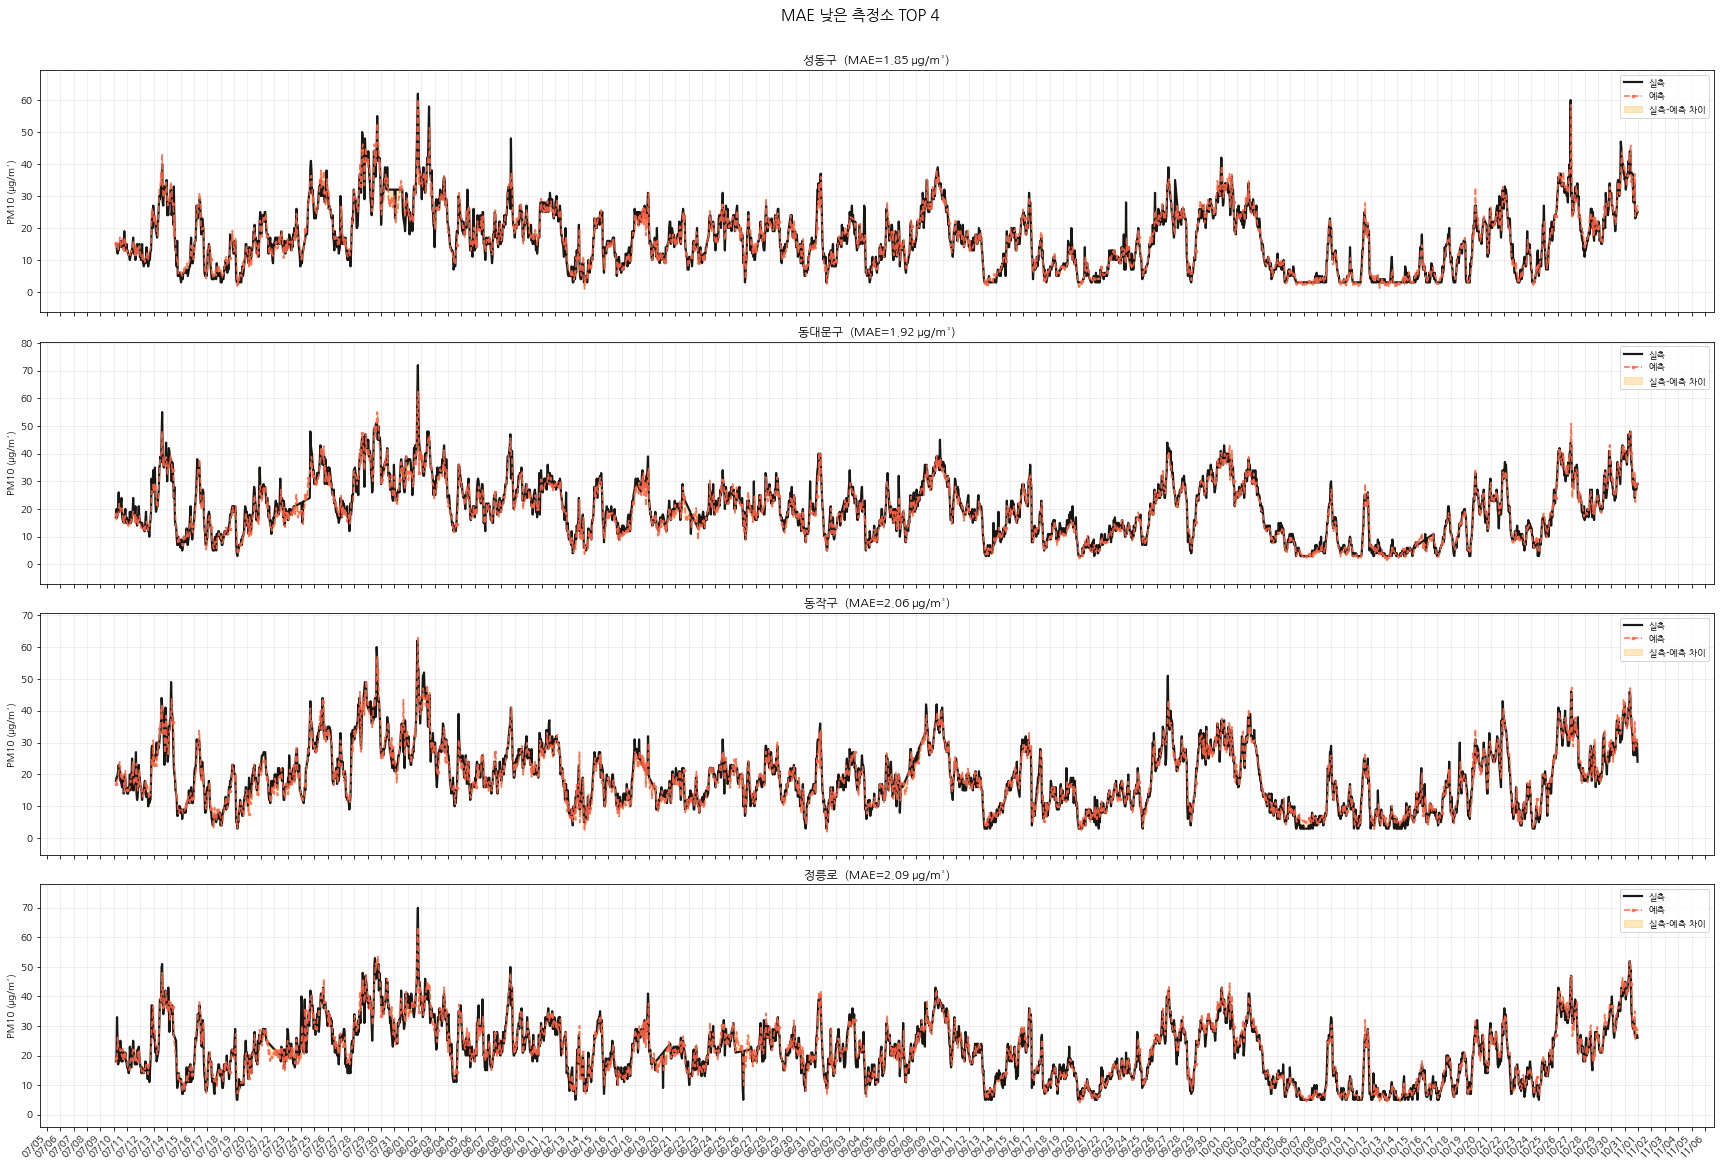

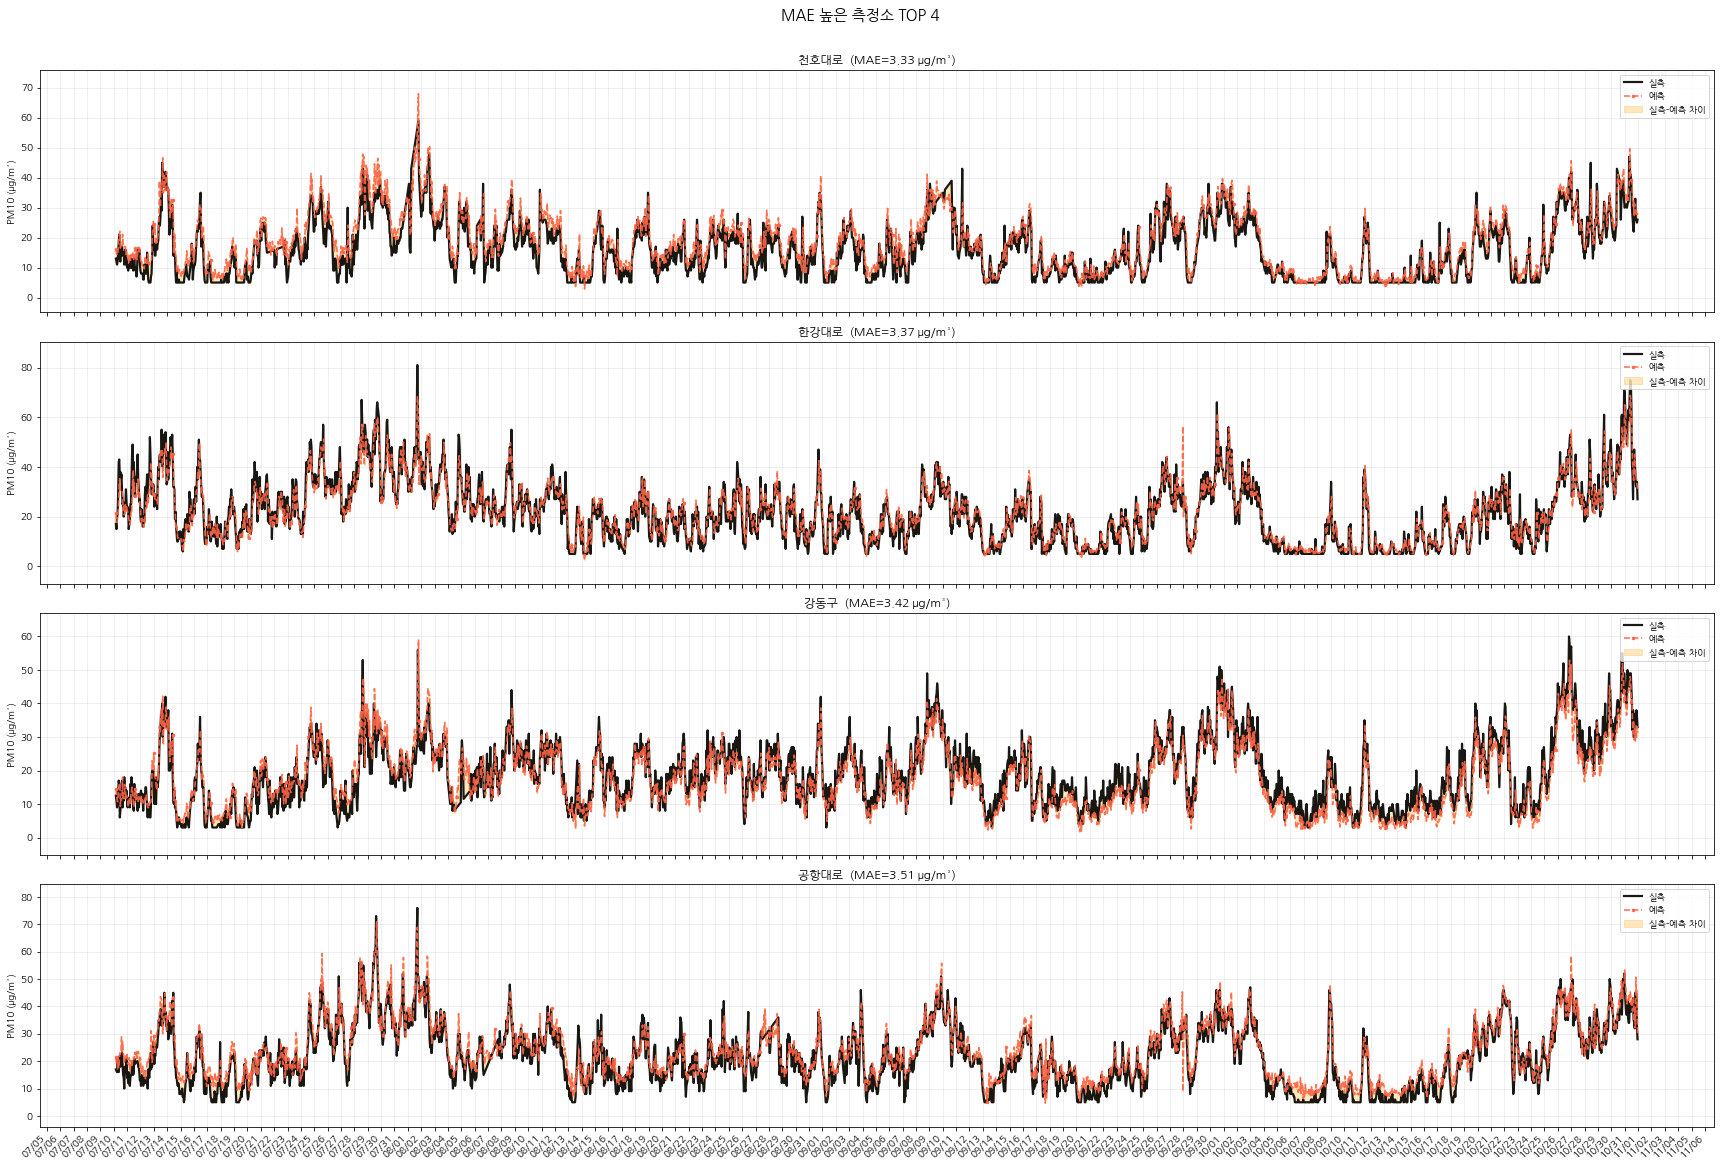

In [9]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

os.makedirs('plots', exist_ok=True)

def plot_station_ts(idxs, title, fname):
    fig, axes = plt.subplots(
        len(idxs), 1,
        figsize=(24, 4 * len(idxs)),
        sharex=True
    )

    if len(idxs) == 1:
        axes = [axes]

    for ax, si in zip(axes, idxs):
        true = true_arr[:, si]
        pred = pred_arr[:, si]

        ax.plot(
            pred_times, true,
            label='실측',
            color='black',
            lw=2.2,
            alpha=0.9,
            zorder=3
        )

        ax.plot(
            pred_times, pred,
            label='예측',
            color='tomato',
            lw=1.6,
            linestyle='--',
            marker='o',
            markersize=2.5,
            markevery=max(1, len(pred_times)//80),
            alpha=0.9,
            zorder=4
        )

        ax.fill_between(
            pred_times, true, pred,
            color='orange',
            alpha=0.25,
            label='실측-예측 차이',
            zorder=2
        )

        ax.set_ylabel('PM10 (μg/m³)', fontsize=10)
        ax.set_title(
            f'{stations[si]}  (MAE={station_mae[si]:.2f} μg/m³)',
            fontsize=12
        )

        ax.grid(alpha=0.25)
        ax.legend(fontsize=9, loc='upper right')

        ymin = min(true.min(), pred.min())
        ymax = max(true.max(), pred.max())
        margin = (ymax - ymin) * 0.12 if ymax > ymin else 1
        ax.set_ylim(ymin - margin, ymax + margin)

    axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

    fig.autofmt_xdate(rotation=45)
    fig.suptitle(title, fontsize=15, y=1.01)

    plt.tight_layout()
    plt.savefig(f'plots/{fname}', dpi=220, bbox_inches='tight')
    plt.show()

plot_station_ts(best4,  'MAE 낮은 측정소 TOP 4', 'timeseries_best4.png')
plot_station_ts(worst4, 'MAE 높은 측정소 TOP 4', 'timeseries_worst4.png')

## 5. 측정소별 MAE 지도 시각화

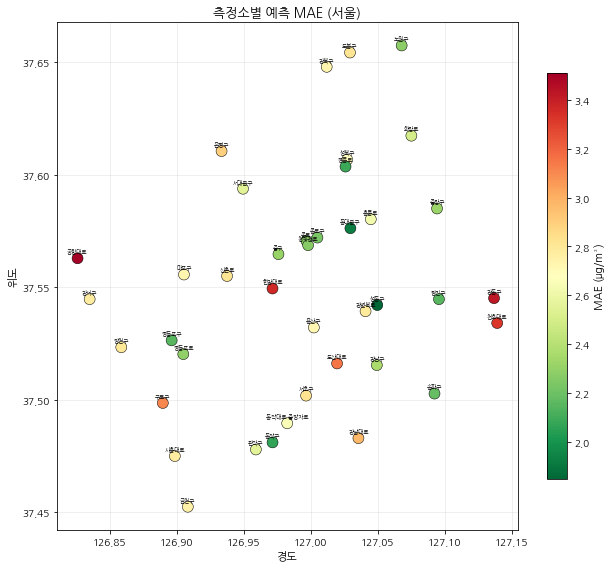

In [10]:
lats = [c[0] for c in coords]
lons = [c[1] for c in coords]

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(
    lons, lats,
    c=station_mae,
    cmap='RdYlGn_r',
    s=120,
    edgecolors='black',
    linewidths=0.5,
    zorder=3,
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('MAE (μg/m³)', fontsize=11)

for i, name in enumerate(stations):
    ax.annotate(
        name, (lons[i], lats[i]),
        fontsize=5.5, ha='center', va='bottom',
        xytext=(0, 4), textcoords='offset points',
    )

ax.set_xlabel('경도', fontsize=11)
ax.set_ylabel('위도', fontsize=11)
ax.set_title('측정소별 예측 MAE (서울)', fontsize=13)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('plots/station_mae_map.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. 측정소별 MAE 순위표

## 7. GAT Attention 분석: 시간 평균 엣지 중요도 (서울 지도)

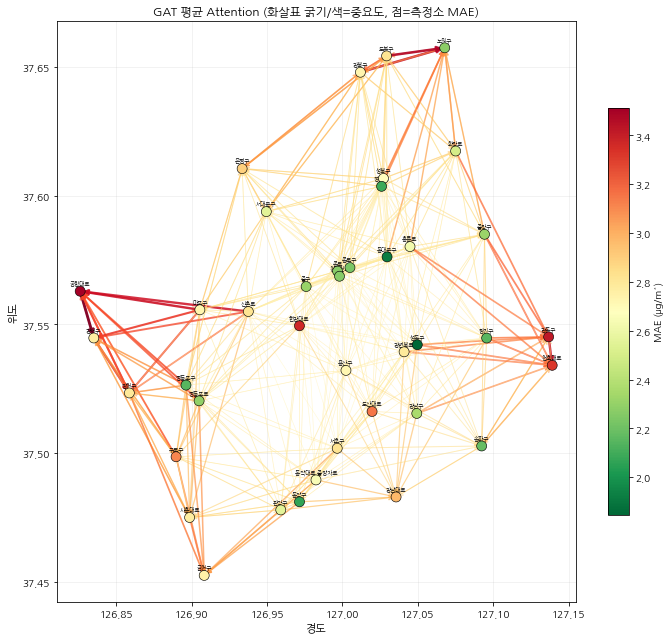

Attention 상위 10개 엣지 (src → dst):
   1. 공항대로         → 강서구           attn=0.1945
   2. 도봉구          → 노원구           attn=0.1772
   3. 강북구          → 노원구           attn=0.1717
   4. 강동구          → 천호대로          attn=0.1676
   5. 마포구          → 공항대로          attn=0.1667
   6. 신촌로          → 공항대로          attn=0.1639
   7. 강서구          → 양천구           attn=0.1547
   8. 마포구          → 강서구           attn=0.1477
   9. 공항대로         → 양천구           attn=0.1462
  10. 마포구          → 양천구           attn=0.1405


In [11]:
# 헤드 평균 attention per edge: [E]
edge_attn = attn_mean.mean(axis=-1)   # [E]

# 정규화 (0~1) for visualization
edge_attn_norm = (edge_attn - edge_attn.min()) / (edge_attn.max() - edge_attn.min() + 1e-8)

lats = np.array([c[0] for c in coords])
lons = np.array([c[1] for c in coords])
src_idx = edge_index_np[0]   # [E]
dst_idx = edge_index_np[1]   # [E]

fig, ax = plt.subplots(figsize=(10, 9))

# 엣지: attention 높을수록 두껍고 진하게
for e in range(len(src_idx)):
    s, d = src_idx[e], dst_idx[e]
    w = edge_attn_norm[e]
    ax.annotate(
        '', xy=(lons[d], lats[d]), xytext=(lons[s], lats[s]),
        arrowprops=dict(
            arrowstyle='->', color=plt.cm.YlOrRd(w),
            lw=0.3 + w * 2.5, alpha=0.3 + w * 0.65,
        )
    )

# 측정소
sc = ax.scatter(lons, lats, c=station_mae, cmap='RdYlGn_r', s=100,
                edgecolors='black', linewidths=0.6, zorder=5)
for i, name in enumerate(stations):
    ax.annotate(name, (lons[i], lats[i]), fontsize=5.5,
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.colorbar(sc, ax=ax, shrink=0.7, label='MAE (μg/m³)')
ax.set_xlabel('경도', fontsize=11)
ax.set_ylabel('위도', fontsize=11)
ax.set_title('GAT 평균 Attention (화살표 굵기/색=중요도, 점=측정소 MAE)', fontsize=12)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('plots/attn_map_mean.png', dpi=180, bbox_inches='tight')
plt.show()

# 상위 10개 엣지 출력
top10 = np.argsort(edge_attn)[::-1][:10]
print("Attention 상위 10개 엣지 (src → dst):")
for rank, e in enumerate(top10, 1):
    print(f"  {rank:2d}. {stations[src_idx[e]]:12s} → {stations[dst_idx[e]]:12s}  attn={edge_attn[e]:.4f}")

## 8. GAT Attention 분석: 고농도 vs 평상시 비교

저농도 배치: 11개  (PM10 ≤ 13.2 μg/m³)
고농도 배치: 11개  (PM10 ≥ 25.1 μg/m³)


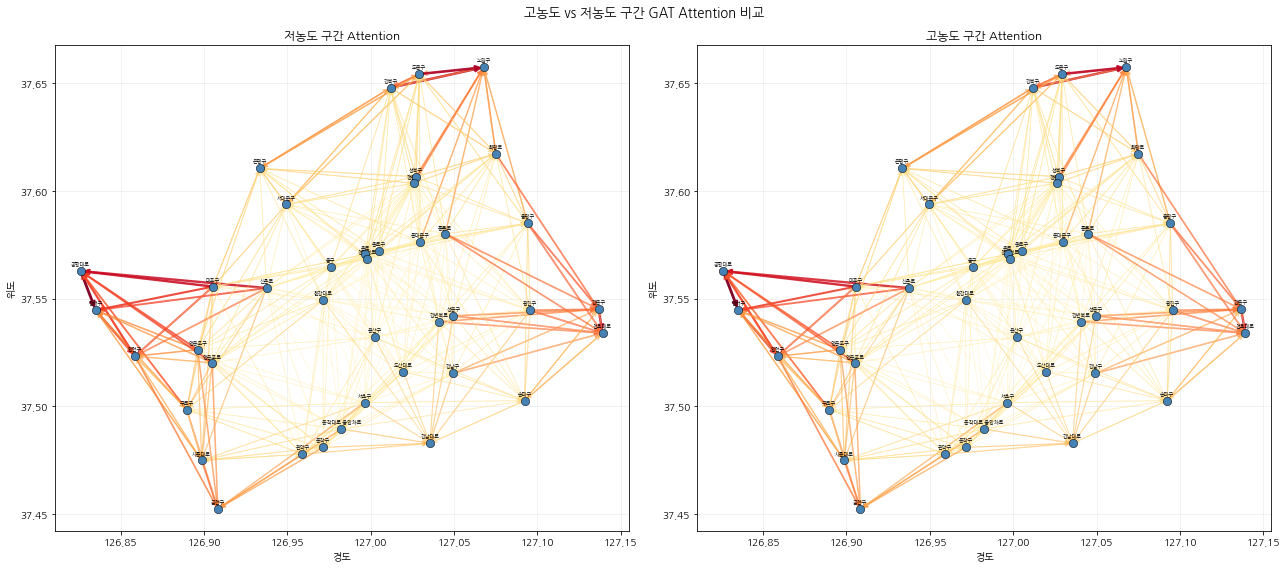


고농도 시 attention 가장 많이 증가한 엣지:
  공항대로         → 강서구           Δ=+0.0078
  강서구          → 양천구           Δ=+0.0075
  공항대로         → 양천구           Δ=+0.0059
  양천구          → 금천구           Δ=+0.0048
  양천구          → 구로구           Δ=+0.0044

고농도 시 attention 가장 많이 감소한 엣지:
  구로구          → 양천구           Δ=-0.0031
  영등포로         → 강서구           Δ=-0.0029
  시흥대로         → 양천구           Δ=-0.0029
  금천구          → 양천구           Δ=-0.0027
  영등포구         → 강서구           Δ=-0.0027


In [12]:
# 배치별 평균 PM10 (실측) 계산
# all_attn: list of [T, E, H] per batch  /  true_arr: [n_samples, N]
batch_size_used = BATCH_SIZE
batch_pm10 = []
for b_start in range(0, len(true_arr), batch_size_used):
    batch_pm10.append(true_arr[b_start:b_start + batch_size_used].mean())
batch_pm10 = np.array(batch_pm10[:len(all_attn)])   # 배치 수 맞춤

q25 = np.percentile(batch_pm10, 25)
q75 = np.percentile(batch_pm10, 75)

low_mask  = batch_pm10 <= q25   # 하위 25%
high_mask = batch_pm10 >= q75   # 상위 25%

attn_low  = attn_per_batch[low_mask].mean(axis=(0, 1))   # [E, H]
attn_high = attn_per_batch[high_mask].mean(axis=(0, 1))  # [E, H]

edge_low  = attn_low.mean(axis=-1)    # [E]
edge_high = attn_high.mean(axis=-1)   # [E]
delta     = edge_high - edge_low      # 고농도일 때 더 주목하는 엣지 (+)

print(f'저농도 배치: {low_mask.sum()}개  (PM10 ≤ {q25:.1f} μg/m³)')
print(f'고농도 배치: {high_mask.sum()}개  (PM10 ≥ {q75:.1f} μg/m³)')

# ── 지도 비교 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
titles = ['저농도 구간 Attention', '고농도 구간 Attention']
for ax, ea, title in zip(axes, [edge_low, edge_high], titles):
    ea_norm = (ea - ea.min()) / (ea.max() - ea.min() + 1e-8)
    for e in range(len(src_idx)):
        s, d = src_idx[e], dst_idx[e]
        w = ea_norm[e]
        ax.annotate('', xy=(lons[d], lats[d]), xytext=(lons[s], lats[s]),
                    arrowprops=dict(arrowstyle='->', color=plt.cm.YlOrRd(w),
                                   lw=0.3 + w * 2.5, alpha=0.3 + w * 0.65))
    ax.scatter(lons, lats, s=70, edgecolors='black', linewidths=0.5,
               color='steelblue', zorder=5)
    for i, name in enumerate(stations):
        ax.annotate(name, (lons[i], lats[i]), fontsize=5,
                    ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('경도'); ax.set_ylabel('위도')
    ax.grid(alpha=0.2)

plt.suptitle('고농도 vs 저농도 구간 GAT Attention 비교', fontsize=13)
plt.tight_layout()
plt.savefig('plots/attn_high_vs_low.png', dpi=180, bbox_inches='tight')
plt.show()

# 고농도 시 attention이 가장 크게 증가/감소하는 엣지
top_increase = np.argsort(delta)[::-1][:5]
top_decrease = np.argsort(delta)[:5]
print("\n고농도 시 attention 가장 많이 증가한 엣지:")
for e in top_increase:
    print(f"  {stations[src_idx[e]]:12s} → {stations[dst_idx[e]]:12s}  Δ={delta[e]:+.4f}")
print("\n고농도 시 attention 가장 많이 감소한 엣지:")
for e in top_decrease:
    print(f"  {stations[src_idx[e]]:12s} → {stations[dst_idx[e]]:12s}  Δ={delta[e]:+.4f}")

## 9. GAT Attention 분석: 풍향별 attention 패턴 (모델이 바람을 이해하는가?)

  북풍 (↓): 0개 배치
  동풍 (←): 13개 배치
  남풍 (↑): 27개 배치
  서풍 (→): 3개 배치


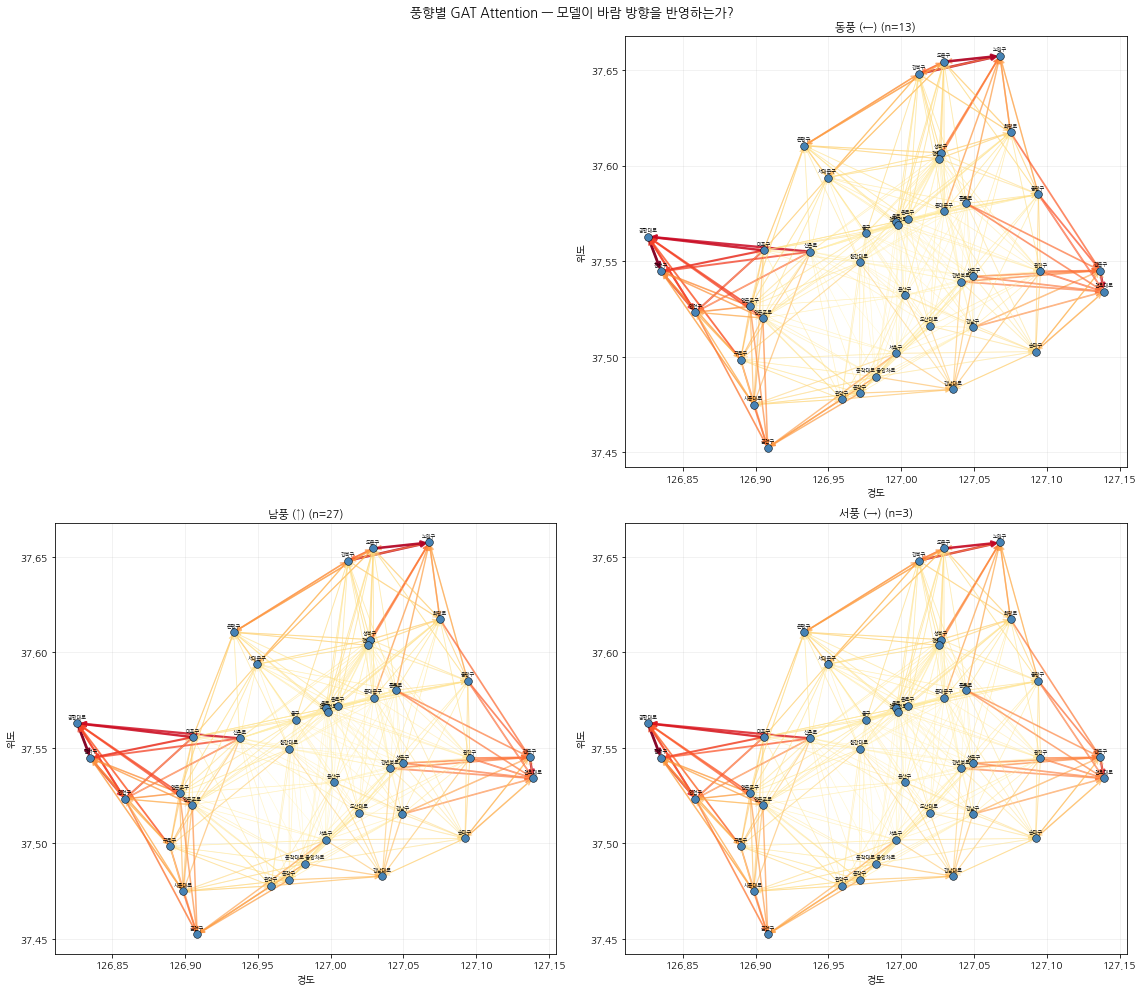


동풍 (←) 상위 3개:
  공항대로         → 강서구           0.1921
  도봉구          → 노원구           0.1768
  강북구          → 노원구           0.1712
남풍 (↑) 상위 3개:
  공항대로         → 강서구           0.1945
  도봉구          → 노원구           0.1772
  강북구          → 노원구           0.1718
서풍 (→) 상위 3개:
  공항대로         → 강서구           0.2044
  도봉구          → 노원구           0.1786
  강북구          → 노원구           0.1731


In [13]:
import pickle

# 테스트 풍향 데이터 로드 (원본 raw 값, 정규화 전)
wind_dir_idx = feature_cols.index('풍향_10m')   # 풍향 feature index

# 배치별 평균 풍향 계산 (test_nodes raw 사용)
batch_winddir = []
for b_start in range(0, len(test_nodes) - WINDOW, batch_size_used):
    chunk = test_nodes[b_start:b_start + batch_size_used + WINDOW, :, wind_dir_idx]
    batch_winddir.append(chunk.mean())
batch_winddir = np.array(batch_winddir[:len(all_attn)])

# 풍향을 4방향으로 분류 (0~360도)
def classify_wind(deg):
    deg = deg % 360
    if deg < 45 or deg >= 315:  return 'N'
    elif deg < 135:              return 'E'
    elif deg < 225:              return 'S'
    else:                        return 'W'

wind_labels = np.array([classify_wind(d) for d in batch_winddir])

directions = ['N', 'E', 'S', 'W']
dir_labels = {'N': '북풍 (↓)', 'E': '동풍 (←)', 'S': '남풍 (↑)', 'W': '서풍 (→)'}
attn_by_dir = {}
for d in directions:
    mask = wind_labels == d
    if mask.sum() > 0:
        attn_by_dir[d] = attn_per_batch[mask].mean(axis=(0, 1)).mean(axis=-1)  # [E]
    print(f"  {dir_labels[d]}: {mask.sum()}개 배치")

# ── 풍향별 지도 2×2 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for ax, d in zip(axes, directions):
    if d not in attn_by_dir:
        ax.set_visible(False)
        continue
    ea = attn_by_dir[d]
    ea_norm = (ea - ea.min()) / (ea.max() - ea.min() + 1e-8)

    for e in range(len(src_idx)):
        s, t_ = src_idx[e], dst_idx[e]
        w = ea_norm[e]
        ax.annotate('', xy=(lons[t_], lats[t_]), xytext=(lons[s], lats[s]),
                    arrowprops=dict(arrowstyle='->', color=plt.cm.YlOrRd(w),
                                   lw=0.3 + w * 2.5, alpha=0.3 + w * 0.65))

    ax.scatter(lons, lats, s=60, edgecolors='black', linewidths=0.5,
               color='steelblue', zorder=5)
    for i, name in enumerate(stations):
        ax.annotate(name, (lons[i], lats[i]), fontsize=5,
                    ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
    ax.set_title(f'{dir_labels[d]} (n={( wind_labels==d).sum()})', fontsize=11)
    ax.set_xlabel('경도'); ax.set_ylabel('위도')
    ax.grid(alpha=0.2)

plt.suptitle('풍향별 GAT Attention — 모델이 바람 방향을 반영하는가?', fontsize=13)
plt.tight_layout()
plt.savefig('plots/attn_by_winddir.png', dpi=180, bbox_inches='tight')
plt.show()

# 풍향별로 attention이 가장 높은 엣지 top3
print()
for d in directions:
    if d not in attn_by_dir:
        continue
    top3 = np.argsort(attn_by_dir[d])[::-1][:3]
    print(f"{dir_labels[d]} 상위 3개:")
    for e in top3:
        print(f"  {stations[src_idx[e]]:12s} → {stations[dst_idx[e]]:12s}  {attn_by_dir[d][e]:.4f}")

In [14]:
station_rmse = np.sqrt(np.mean((pred_arr - true_arr) ** 2, axis=0))

df_result = pd.DataFrame({
    '측정소': stations,
    'MAE':    np.round(station_mae, 2),
    'RMSE':   np.round(station_rmse, 2),
}).sort_values('MAE').reset_index(drop=True)

df_result.index += 1
print(df_result.to_string())

          측정소   MAE  RMSE
1         성동구  1.85  2.61
2        동대문구  1.92  2.61
3         동작구  2.06  2.77
4         정릉로  2.09  2.82
5         광진구  2.15  2.93
6        영등포구  2.15  2.92
7         송파구  2.18  2.87
8         종로구  2.23  3.10
9        청계천로  2.26  3.21
10         종로  2.27  3.20
11        노원구  2.28  3.04
12       영등포로  2.29  3.11
13         중구  2.31  3.09
14        중랑구  2.32  3.14
15        강남구  2.36  3.40
16        화랑로  2.50  3.42
17       서대문구  2.55  3.43
18        관악구  2.56  3.47
19        홍릉로  2.62  3.61
20  동작대로 중앙차로  2.65  3.69
21        성북구  2.68  3.58
22        용산구  2.72  3.78
23        강북구  2.73  3.55
24        마포구  2.74  8.06
25        금천구  2.75  3.75
26       시흥대로  2.77  4.02
27        강서구  2.77  3.66
28       강변북로  2.79  3.70
29        양천구  2.80  3.70
30        도봉구  2.81  3.70
31        신촌로  2.81  3.79
32        서초구  2.83  3.75
33        은평구  2.90  3.85
34       강남대로  2.97  3.99
35        구로구  3.11  4.11
36       도산대로  3.16  4.21
37       천호대로  3.33  4.26
38       한강대